# 10. Xarray Integration
Seamlessly integrate `curaster` outputs into the broader Python data science ecosystem by converting `RasterResult` to an `xarray.DataArray`.

In [1]:
import curaster
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

input_file = "../build/benchmark_data/test_S_2048x2048.tif"

## Get Metadata and Data
Extract geotransform coordinates and pixel data.

In [2]:
%%time
# Get Metadata
info = curaster.open(input_file).get_info()
gt = info["geotransform"]

# Execute processing and get data
result = curaster.open(input_file) \
    .algebra("B1 * 0.5") \
    .to_memory()

arr = result.data()
arr[arr == -9999.0] = np.nan

CPU times: user 192 ms, sys: 229 ms, total: 422 ms
Wall time: 319 ms


## Construct Xarray DataArray
Calculate the x and y coordinates using the affine geotransform.

In [3]:
xcoords = gt[0] + np.arange(result.width)  * gt[1]
ycoords = gt[3] + np.arange(result.height) * gt[5]

da = xr.DataArray(
    arr, 
    dims=["y", "x"], 
    coords={"x": xcoords, "y": ycoords},
    attrs={"crs": result.proj}
)

print("Xarray DataArray:")
print(da)

Xarray DataArray:
<xarray.DataArray (y: 2048, x: 2048)> Size: 17MB
array([[2213.5, 2045.5, 2256. , ..., 1846. , 2048.5, 2099.5],
       [1909. , 2004. , 2331.5, ..., 1928.5, 1945. , 1997.5],
       [2142.5, 2158. , 2190.5, ..., 1924. , 1893.5, 2167. ],
       ...,
       [2070. , 2139. , 2014.5, ..., 1946.5, 2195.5, 1894.5],
       [1821.5, 2155.5, 1998. , ..., 2267. , 2040.5, 1913.5],
       [2196. , 1875. , 2227.5, ..., 2014.5, 1866. , 1892. ]],
      shape=(2048, 2048), dtype=float32)
Coordinates:
  * y        (y) float64 16kB 4.66e+06 4.66e+06 4.66e+06 ... 4.64e+06 4.64e+06
  * x        (x) float64 16kB 3.3e+05 3.3e+05 3.3e+05 ... 3.505e+05 3.505e+05
Attributes:
    crs:      PROJCS["WGS 84 / UTM zone 33N",GEOGCS["WGS 84",DATUM["WGS_1984"...


## Plot with Xarray

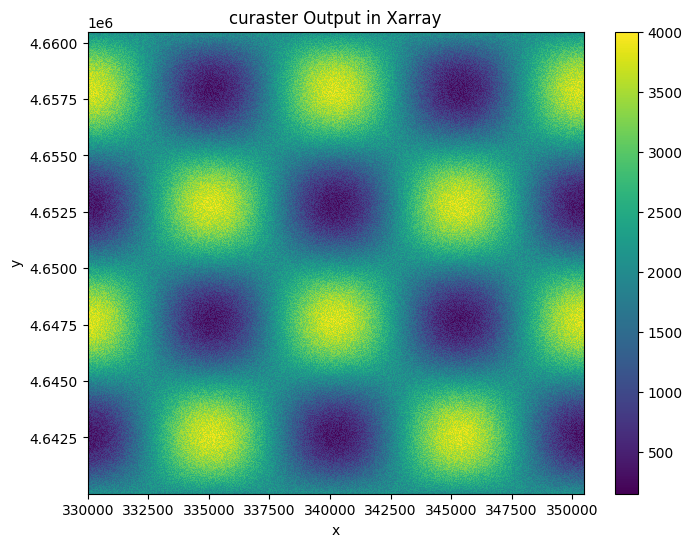

In [4]:
da.plot(cmap="viridis", figsize=(8, 6))
plt.title("curaster Output in Xarray")
plt.show()